## Generalization 1: CIFAR-100 + ResNet-18
### Taylor Importance · Iterative Prune-Then-Recover · Knowledge Distillation

In [23]:
%pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
%pip install -q torch-pruning networkx codecarbon thop psutil

In [24]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

EXPERIMENT_NAME = 'cifar100_resnet18'
DRIVE_ROOT      = f'/content/drive/MyDrive/pruning_research/{EXPERIMENT_NAME}'
os.makedirs(DRIVE_ROOT, exist_ok=True)
print(f'Drive root: {DRIVE_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/pruning_research/cifar100_resnet18


### Checkpoint / Resume
Each stage saves to Google Drive automatically. If your session crashes, re-run from the **Resume** cell at the start of that stage — completed stages are skipped instantly.

In [25]:
# ── Checkpoint & Resume Utilities ───────────────────────────────────────────
# Call save_checkpoint() after any expensive stage.
# Call load_checkpoint() at the top of a resumed session to skip redoing work.


def save_checkpoint(tag, model, extra_metrics=None):
    """Save model weights + metrics dict to Drive under a stage tag.
    tag: short string e.g. 'baseline', 'prune_step_2', 'final'
    extra_metrics: dict of scalars to persist alongside weights
    """
    path = f"{DRIVE_ROOT}/{tag}.pth"
    payload = {"state_dict": model.state_dict(), "metrics": extra_metrics or {}}
    torch.save(payload, path)
    print(f"  ✓ Checkpoint saved → {path}")


def load_checkpoint(tag, model):
    """Load weights from Drive checkpoint. Returns metrics dict.
    Returns None if checkpoint does not exist (fresh run).
    """
    path = f"{DRIVE_ROOT}/{tag}.pth"
    if not os.path.exists(path):
        print(f'  No checkpoint found for tag "{tag}" — starting fresh.')
        return None
    payload = torch.load(path, map_location=device)
    model.load_state_dict(payload["state_dict"])
    print(f"  ✓ Checkpoint loaded ← {path}")
    return payload.get("metrics", {})


def checkpoint_exists(tag):
    """Check if a stage has already been completed in a previous session."""
    return os.path.exists(f"{DRIVE_ROOT}/{tag}.pth")


def save_results_csv(metrics_dict):
    """Append a results row to a shared CSV in Drive for cross-notebook
    aggregation (seeds, ablations, baselines).
    """
    import pandas as pd

    csv_path = "/content/drive/MyDrive/pruning_research/all_results.csv"
    row = {"experiment": EXPERIMENT_NAME, **metrics_dict}
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])
    df.to_csv(csv_path, index=False)
    print(f"  ✓ Results appended → {csv_path}")


print("Checkpoint utilities ready.")
print(f"Existing checkpoints in {DRIVE_ROOT}:")
existing = [f for f in os.listdir(DRIVE_ROOT) if f.endswith(".pth")]
print(" ", existing if existing else "none — fresh run")

Checkpoint utilities ready.
Existing checkpoints in /content/drive/MyDrive/pruning_research/cifar100_resnet18:
  none — fresh run


### Cell 2: Imports and Reproducibility

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import random
import os
import copy
import pandas as pd
import matplotlib.pyplot as plt
import torchao
from torchao.quantization import int8_dynamic_activation_int8_weight

from codecarbon import EmissionsTracker
from thop import profile
import torch_pruning as tp


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Cell 3: Data Preparation with Augmentation

In [27]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5071,0.4867,0.4408),(0.2675,0.2565,0.2761))
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5071,0.4867,0.4408),(0.2675,0.2565,0.2761))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True,  download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=test_transform)

train_subset = Subset(trainset, range(10000))
trainloader  = DataLoader(train_subset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
testloader   = DataLoader(testset,      batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

### Cell 4: Utility Functions

In [28]:
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    """Standard training epoch. Supports AMP via optional GradScaler."""
    model.train()
    correct, total = 0, 0
    use_amp = (scaler is not None) and (device.type == "cuda")
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            out = model(x)
            loss = criterion(out, y)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()
    return 100.0 * correct / total


def train_epoch_distill(
    student, teacher, loader, optimizer, criterion, T=4.0, alpha=0.7, scaler=None
):
    """KD training epoch. Supports AMP via optional GradScaler.
    Loss = alpha * KL(soft targets) + (1-alpha) * CE(hard labels)
    """
    student.train()
    teacher.eval()
    correct, total = 0, 0
    use_amp = (scaler is not None) and (device.type == "cuda")
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=use_amp):
            with torch.no_grad():
                teacher_logits = teacher(x)
            student_logits = student(x)
            kl_loss = F.kl_div(
                F.log_softmax(student_logits / T, dim=1),
                F.softmax(teacher_logits / T, dim=1),
                reduction="batchmean",
            ) * (T**2)
            ce_loss = criterion(student_logits, y)
            loss = alpha * kl_loss + (1 - alpha) * ce_loss
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        _, pred = student_logits.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()
    return 100.0 * correct / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
    return 100.0 * correct / total


def model_size(model):
    return sum(p.numel() for p in model.parameters()) / 1e6


def latency_bs1(model, runs=50):
    model.eval()
    x = torch.randn(1, 3, 224, 224).to(device)
    times = []
    with torch.no_grad():
        for _ in range(runs):
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.time()
            model(x)
            if device.type == "cuda":
                torch.cuda.synchronize()
            times.append(time.time() - t0)
    return np.mean(times) * 1000


# AMP scaler — active on CUDA, no-op on CPU
scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None
print(f"AMP enabled: {scaler is not None}")

AMP enabled: True


### Cell 5: Baseline Model Training

In [29]:
# ── Resume guard: skip if baseline already done ────────────────────────────
if checkpoint_exists("baseline"):
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(512, 100)  # CIFAR-100
    model = model.to(device)
    metrics = load_checkpoint("baseline", model)
    baseline_acc = metrics["baseline_acc"]
    baseline_params = metrics["baseline_params"]
    baseline_flops = metrics["baseline_flops"]
    baseline_latency = metrics["baseline_latency"]
    baseline_emissions = metrics["baseline_emissions"]
    teacher_model = copy.deepcopy(model)
    for p in teacher_model.parameters():
        p.requires_grad = False
    teacher_model.eval()
    criterion = nn.CrossEntropyLoss()
    print(f"BASELINE RESUMED — Accuracy: {baseline_acc:.2f}%")
else:
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(512, 100)  # CIFAR-100
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # ── Phase 1: Warm up the head only (3 epochs) ──
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
    print("=== Phase 1: Head warmup (3 epochs) ===")
    for epoch in range(3):
        acc = train_epoch(model, trainloader, optimizer, criterion, scaler=scaler)
        print(f"  Epoch {epoch + 1}/3 | Train Acc {acc:.2f}%")

    # ── Phase 2: Full fine-tune with differential LRs (4 epochs) ──
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(
        [
            {"params": model.layer1.parameters(), "lr": 1e-5},
            {"params": model.layer2.parameters(), "lr": 1e-5},
            {"params": model.layer3.parameters(), "lr": 5e-5},
            {"params": model.layer4.parameters(), "lr": 1e-4},
            {"params": model.fc.parameters(), "lr": 5e-4},
        ],
        lr=1e-5,
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=4)

    print("=== Phase 2: Full fine-tune with differential LRs (4 epochs) ===")
    tracker = EmissionsTracker(log_level="error")
    tracker.start()

    for epoch in range(4):
        acc = train_epoch(model, trainloader, optimizer, criterion, scaler=scaler)
        scheduler.step()
        val_acc = evaluate(model, testloader)
        print(f"  Epoch {epoch + 1}/4 | Train Acc {acc:.2f}% | Val Acc {val_acc:.2f}%")

    baseline_acc = evaluate(model, testloader)
    baseline_emissions = tracker.stop()
    baseline_flops, _ = profile(
        model, inputs=(torch.randn(1, 3, 224, 224).to(device),), verbose=False
    )
    baseline_params = model_size(model)
    baseline_latency = latency_bs1(model)

    print(f"\nBASELINE RESULTS")
    print(f"  Accuracy : {baseline_acc:.2f}%")
    print(f"  Params   : {baseline_params:.2f} M")
    print(f"  FLOPs    : {baseline_flops / 1e9:.2f} G")
    print(f"  Latency  : {baseline_latency:.2f} ms")

    # Keep a frozen copy as the teacher for distillation later
    teacher_model = copy.deepcopy(model)
    for p in teacher_model.parameters():
        p.requires_grad = False
    teacher_model.eval()
    print("Teacher model saved.")

    save_checkpoint(
        "baseline",
        model,
        {
            "baseline_acc": baseline_acc,
            "baseline_params": baseline_params,
            "baseline_flops": baseline_flops,
            "baseline_latency": baseline_latency,
            "baseline_emissions": baseline_emissions,
        },
    )

=== Phase 1: Head warmup (3 epochs) ===
  Epoch 1/3 | Train Acc 14.89%
  Epoch 2/3 | Train Acc 37.65%


[codecarbon WARNING @ 12:39:47] Multiple instances of codecarbon are allowed to run at the same time.


  Epoch 3/3 | Train Acc 47.36%
=== Phase 2: Full fine-tune with differential LRs (4 epochs) ===
  Epoch 1/4 | Train Acc 60.75% | Val Acc 64.08%
  Epoch 2/4 | Train Acc 74.10% | Val Acc 67.81%
  Epoch 3/4 | Train Acc 80.46% | Val Acc 69.79%
  Epoch 4/4 | Train Acc 85.14% | Val Acc 70.47%

BASELINE RESULTS
  Accuracy : 70.47%
  Params   : 11.23 M
  FLOPs    : 1.82 G
  Latency  : 2.89 ms
Teacher model saved.
  ✓ Checkpoint saved → /content/drive/MyDrive/pruning_research/cifar100_resnet18/baseline.pth


### Cell 6: Iterative Structured Pruning with Taylor Importance

In [30]:
print("=== ITERATIVE PRUNING WITH TAYLOR IMPORTANCE (prune-then-recover) ===")

PRUNING_RATIO = 0.40  # 40% total channel reduction
ITERATIVE_STEPS = 5  # 5 prune steps
TAYLOR_GRAD_BATCHES = 5  # batches for stable Taylor gradient accumulation
RECOVER_EPOCHS = 2  # KD fine-tune epochs between each prune step

example_inputs = torch.randn(1, 3, 224, 224).to(device)

for param in model.parameters():
    param.requires_grad = True

imp = tp.importance.TaylorImportance()

pruner = tp.pruner.MetaPruner(
    model,
    example_inputs,
    importance=imp,
    pruning_ratio=PRUNING_RATIO,
    iterative_steps=ITERATIVE_STEPS,
    ignored_layers=[model.fc],
    round_to=8,  # round pruned channel counts to multiples of 8
    # keeps CUDA kernel sizes aligned → real latency speedup
)

# Separate optimizer for recovery fine-tuning between steps
recover_scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

for step in range(ITERATIVE_STEPS):
    # ── 1. Accumulate Taylor gradients over multiple batches ──
    model.train()
    optimizer_prune = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    optimizer_prune.zero_grad()
    batches_seen = 0
    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y) / TAYLOR_GRAD_BATCHES
        loss.backward()
        batches_seen += 1
        if batches_seen >= TAYLOR_GRAD_BATCHES:
            break

    # ── 2. Prune one step ──
    pruner.step()
    params_after = model_size(model)
    acc_after = evaluate(model, testloader)
    print(
        f"  [Prune {step + 1}/{ITERATIVE_STEPS}] Params: {params_after:.2f}M | "
        f"Val Acc pre-recover: {acc_after:.2f}%"
    )

    # ── 3. Mini KD recovery — rebuilds representations before next prune ──
    for param in model.parameters():
        param.requires_grad = True
    recover_optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    recover_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        recover_optimizer, T_max=RECOVER_EPOCHS
    )
    for rep_epoch in range(RECOVER_EPOCHS):
        train_epoch_distill(
            student=model,
            teacher=teacher_model,
            loader=trainloader,
            optimizer=recover_optimizer,
            criterion=criterion,
            T=4.0,
            alpha=0.7,
            scaler=recover_scaler,
        )
        recover_scheduler.step()

    acc_recovered = evaluate(model, testloader)
    print(
        f"  [Recover {step + 1}/{ITERATIVE_STEPS}] Val Acc post-recover: {acc_recovered:.2f}%"
    )
    save_checkpoint(
        f"prune_step_{step + 1}",
        model,
        {"val_acc": acc_recovered, "params_m": model_size(model)},
    )

print("\nIterative prune-then-recover complete.")

=== ITERATIVE PRUNING WITH TAYLOR IMPORTANCE (prune-then-recover) ===
  [Prune 1/5] Params: 9.18M | Val Acc pre-recover: 31.18%
  [Recover 1/5] Val Acc post-recover: 67.83%
  ✓ Checkpoint saved → /content/drive/MyDrive/pruning_research/cifar100_resnet18/prune_step_1.pth
  [Prune 2/5] Params: 7.60M | Val Acc pre-recover: 51.97%
  [Recover 2/5] Val Acc post-recover: 69.11%
  ✓ Checkpoint saved → /content/drive/MyDrive/pruning_research/cifar100_resnet18/prune_step_2.pth
  [Prune 3/5] Params: 6.33M | Val Acc pre-recover: 61.83%
  [Recover 3/5] Val Acc post-recover: 69.11%
  ✓ Checkpoint saved → /content/drive/MyDrive/pruning_research/cifar100_resnet18/prune_step_3.pth
  [Prune 4/5] Params: 4.98M | Val Acc pre-recover: 44.78%
  [Recover 4/5] Val Acc post-recover: 69.17%
  ✓ Checkpoint saved → /content/drive/MyDrive/pruning_research/cifar100_resnet18/prune_step_4.pth
  [Prune 5/5] Params: 3.93M | Val Acc pre-recover: 38.60%
  [Recover 5/5] Val Acc post-recover: 69.45%
  ✓ Checkpoint saved → 

### Cell 7: Fine-tuning with Knowledge Distillation + Cosine LR

In [31]:
# ── Resume guard: skip fine-tuning if final checkpoint exists ───────────────
if checkpoint_exists("final"):
    # Rebuild model architecture first (pruned structure must match)
    metrics = load_checkpoint("final", model)
    pruned_acc = metrics["pruned_acc"]
    pruned_params = metrics["pruned_params"]
    pruned_flops = metrics["pruned_flops"]
    pruned_latency = metrics["pruned_latency"]
    pruned_emissions = metrics["pruned_emissions"]
    print(f"FINE-TUNING RESUMED — Final Accuracy: {pruned_acc:.2f}%")
else:
    FINETUNE_EPOCHS = 10
    KD_TEMPERATURE = 4.0
    KD_ALPHA = 0.7

    for p in model.parameters():
        p.requires_grad = True

    optimizer_ft = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    # Lower starting LR (1e-4 vs 3e-4) — model is already partially recovered
    # from prune-then-recover, so we need polish not aggressive updates
    scheduler_ft = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer_ft, T_0=3, T_mult=2
    )

    # Fixed: use torch.amp instead of deprecated torch.cuda.amp
    ft_scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    print(
        f"=== FINAL FINE-TUNING WITH KNOWLEDGE DISTILLATION ({FINETUNE_EPOCHS} epochs) ==="
    )
    tracker = EmissionsTracker(log_level="error")
    tracker.start()

    best_acc = 0.0
    best_state = None

    for epoch in range(FINETUNE_EPOCHS):
        train_acc = train_epoch_distill(
            student=model,
            teacher=teacher_model,
            loader=trainloader,
            optimizer=optimizer_ft,
            criterion=criterion,
            T=KD_TEMPERATURE,
            alpha=KD_ALPHA,
            scaler=ft_scaler,
        )
        scheduler_ft.step()
        val_acc = evaluate(model, testloader)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        lr_now = optimizer_ft.param_groups[0]["lr"]
        print(
            f"  Epoch {epoch + 1:02d}/{FINETUNE_EPOCHS} | "
            f"Train Acc {train_acc:.2f}% | "
            f"Val Acc {val_acc:.2f}% | "
            f"LR {lr_now:.2e}"
        )

    model.load_state_dict(best_state)
    print(f"\nBest val acc during fine-tuning: {best_acc:.2f}%")

    pruned_acc = evaluate(model, testloader)
    pruned_emissions = tracker.stop()
    pruned_flops, _ = profile(
        model, inputs=(torch.randn(1, 3, 224, 224).to(device),), verbose=False
    )
    pruned_params = model_size(model)
    pruned_latency = latency_bs1(model)

    save_checkpoint(
        "final",
        model,
        {
            "pruned_acc": pruned_acc,
            "pruned_params": pruned_params,
            "pruned_flops": pruned_flops,
            "pruned_latency": pruned_latency,
            "pruned_emissions": pruned_emissions,
        },
    )
    # Append this experiment's results to the shared CSV
    save_results_csv(
        {
            "baseline_acc": baseline_acc,
            "pruned_acc": pruned_acc,
            "baseline_params": baseline_params,
            "pruned_params": pruned_params,
            "baseline_flops": baseline_flops / 1e9,
            "pruned_flops": pruned_flops / 1e9,
            "baseline_latency": baseline_latency,
            "pruned_latency": pruned_latency,
        }
    )

=== FINAL FINE-TUNING WITH KNOWLEDGE DISTILLATION (10 epochs) ===
  Epoch 01/10 | Train Acc 90.62% | Val Acc 71.18% | LR 7.50e-05
  Epoch 02/10 | Train Acc 92.28% | Val Acc 71.18% | LR 2.50e-05
  Epoch 03/10 | Train Acc 92.63% | Val Acc 71.44% | LR 1.00e-04
  Epoch 04/10 | Train Acc 92.79% | Val Acc 71.18% | LR 9.33e-05
  Epoch 05/10 | Train Acc 93.27% | Val Acc 71.22% | LR 7.50e-05
  Epoch 06/10 | Train Acc 94.03% | Val Acc 71.58% | LR 5.00e-05
  Epoch 07/10 | Train Acc 94.16% | Val Acc 71.78% | LR 2.50e-05
  Epoch 08/10 | Train Acc 94.94% | Val Acc 71.86% | LR 6.70e-06
  Epoch 09/10 | Train Acc 94.65% | Val Acc 71.80% | LR 1.00e-04
  Epoch 10/10 | Train Acc 94.58% | Val Acc 71.95% | LR 9.83e-05

Best val acc during fine-tuning: 71.95%
  ✓ Checkpoint saved → /content/drive/MyDrive/pruning_research/cifar100_resnet18/final.pth
  ✓ Results appended → /content/drive/MyDrive/pruning_research/all_results.csv


### Cell 8: Final Results

In [32]:
print("\n" + "=" * 70)
print("FINAL RESULTS TABLE")
print("=" * 70)
print(f"{'Metric':<22}{'Baseline':>12}{'Pruned':>12}{'Change':>12}")
print("-" * 70)
print(
    f"{'Accuracy (%)':<22}{baseline_acc:>12.2f}{pruned_acc:>12.2f}{pruned_acc - baseline_acc:>+11.2f}"
)
print(
    f"{'Params (M)':<22}{baseline_params:>12.2f}{pruned_params:>12.2f}{pruned_params / baseline_params * 100 - 100:>+10.1f}%"
)
print(
    f"{'FLOPs (G)':<22}{baseline_flops / 1e9:>12.2f}{pruned_flops / 1e9:>12.2f}{pruned_flops / baseline_flops * 100 - 100:>+10.1f}%"
)
print(
    f"{'Latency (ms)':<22}{baseline_latency:>12.2f}{pruned_latency:>12.2f}{pruned_latency / baseline_latency * 100 - 100:>+10.1f}%"
)
print(
    f"{'CO2 (g)':<22}{baseline_emissions:>12.4f}{pruned_emissions:>12.4f}{pruned_emissions / baseline_emissions * 100 - 100:>+10.1f}%"
)
print("=" * 70)


FINAL RESULTS TABLE
Metric                    Baseline      Pruned      Change
----------------------------------------------------------------------
Accuracy (%)                 70.47       71.95      +1.48
Params (M)                   11.23        3.93     -65.0%
FLOPs (G)                     1.82        0.60     -67.3%
Latency (ms)                  2.89        2.24     -22.6%
CO2 (g)                     0.0026      0.0060    +128.5%


### Cell 9: Metrics DataFrame

In [33]:
data = {
    "Metric": ["Accuracy (%)", "Params (M)", "FLOPs (G)", "Latency (ms)"],
    "Baseline": [
        baseline_acc,
        baseline_params,
        baseline_flops / 1e9,
        float(baseline_latency),
    ],
    "Pruned": [pruned_acc, pruned_params, pruned_flops / 1e9, float(pruned_latency)],
}
df_metrics = pd.DataFrame(data)
df_metrics["Change (%)"] = (
    (df_metrics["Pruned"] - df_metrics["Baseline"]) / df_metrics["Baseline"]
) * 100

display(df_metrics.round(3))

baseline_acc_val = df_metrics.loc[0, "Baseline"]
pruned_acc_val = df_metrics.loc[0, "Pruned"]
baseline_params_val = df_metrics.loc[1, "Baseline"]
pruned_params_val = df_metrics.loc[1, "Pruned"]
baseline_flops_val = df_metrics.loc[2, "Baseline"]
pruned_flops_val = df_metrics.loc[2, "Pruned"]
baseline_lat_val = df_metrics.loc[3, "Baseline"]
pruned_lat_val = df_metrics.loc[3, "Pruned"]

,Metric,Baseline,Pruned,Change (%)
0,Accuracy (%),70.470,71.950,2.100
1,Params (M),11.228,3.931,-64.987
2,FLOPs (G),1.824,0.596,-67.300
3,Latency (ms),2.888,2.237,-22.551


### Accuracy vs Model Size

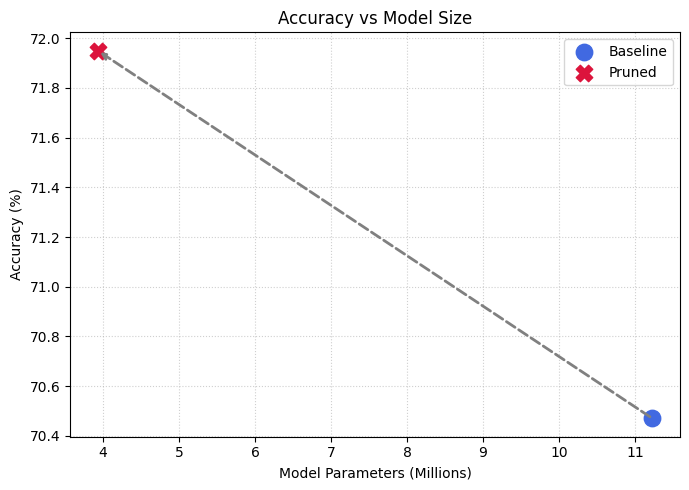

In [34]:
plt.figure(figsize=(7, 5))
plt.scatter(
    baseline_params_val,
    baseline_acc_val,
    color="royalblue",
    s=140,
    label="Baseline",
    marker="o",
    zorder=3,
)
plt.scatter(
    pruned_params_val,
    pruned_acc_val,
    color="crimson",
    s=140,
    label="Pruned",
    marker="X",
    zorder=3,
)
plt.annotate(
    "",
    xy=(pruned_params_val, pruned_acc_val),
    xytext=(baseline_params_val, baseline_acc_val),
    arrowprops=dict(arrowstyle="->", lw=2, color="gray", linestyle="--"),
)
plt.xlabel("Model Parameters (Millions)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Model Size")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### FLOPs vs Latency

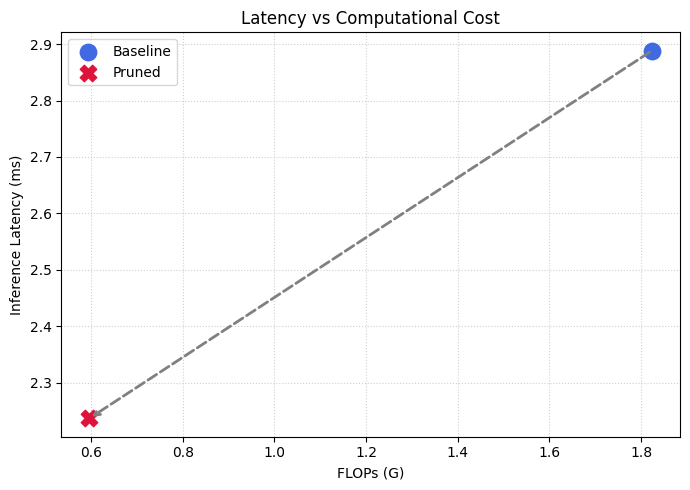

In [35]:
plt.figure(figsize=(7, 5))
plt.scatter(
    baseline_flops_val,
    baseline_lat_val,
    color="royalblue",
    s=140,
    label="Baseline",
    marker="o",
    zorder=3,
)
plt.scatter(
    pruned_flops_val,
    pruned_lat_val,
    color="crimson",
    s=140,
    label="Pruned",
    marker="X",
    zorder=3,
)
plt.annotate(
    "",
    xy=(pruned_flops_val, pruned_lat_val),
    xytext=(baseline_flops_val, baseline_lat_val),
    arrowprops=dict(arrowstyle="->", lw=2, color="gray", linestyle="--"),
)
plt.xlabel("FLOPs (G)")
plt.ylabel("Inference Latency (ms)")
plt.title("Latency vs Computational Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Accuracy vs FLOPs

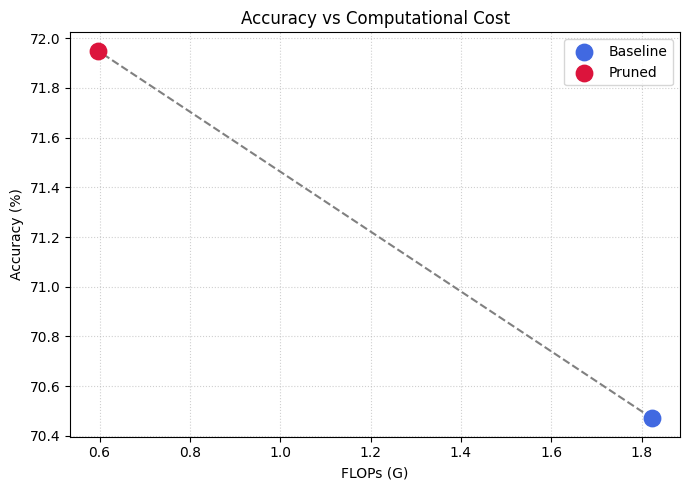

In [36]:
plt.figure(figsize=(7, 5))
plt.scatter(
    baseline_flops_val,
    baseline_acc_val,
    color="royalblue",
    s=140,
    label="Baseline",
    zorder=3,
)
plt.scatter(
    pruned_flops_val, pruned_acc_val, color="crimson", s=140, label="Pruned", zorder=3
)
plt.plot(
    [baseline_flops_val, pruned_flops_val],
    [baseline_acc_val, pruned_acc_val],
    linestyle="--",
    color="gray",
)
plt.xlabel("FLOPs (G)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Computational Cost")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Compression Comparison Bar Chart

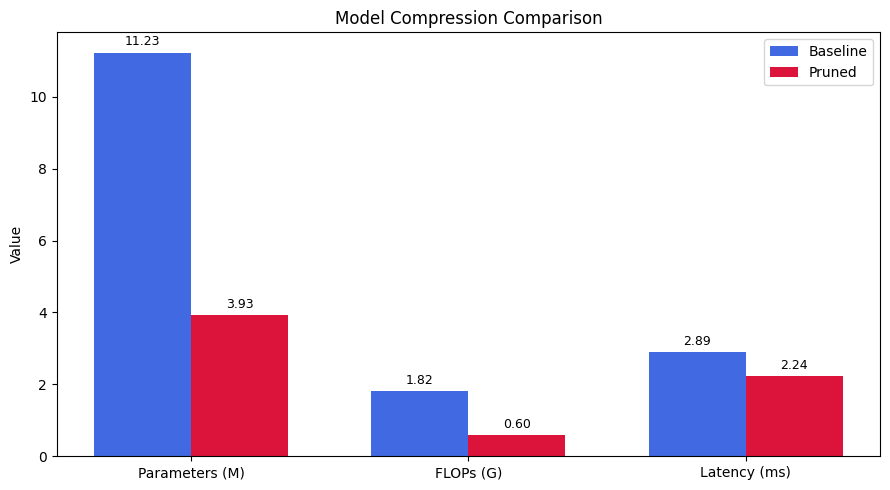

In [37]:
metrics_labels = ["Parameters (M)", "FLOPs (G)", "Latency (ms)"]
baseline_vals = [baseline_params_val, baseline_flops_val, baseline_lat_val]
pruned_vals = [pruned_params_val, pruned_flops_val, pruned_lat_val]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, baseline_vals, width, label="Baseline", color="royalblue")
bars2 = ax.bar(x + width / 2, pruned_vals, width, label="Pruned", color="crimson")

ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel("Value")
ax.set_title("Model Compression Comparison")
ax.legend()
plt.tight_layout()
plt.show()

### Combined Research Figure

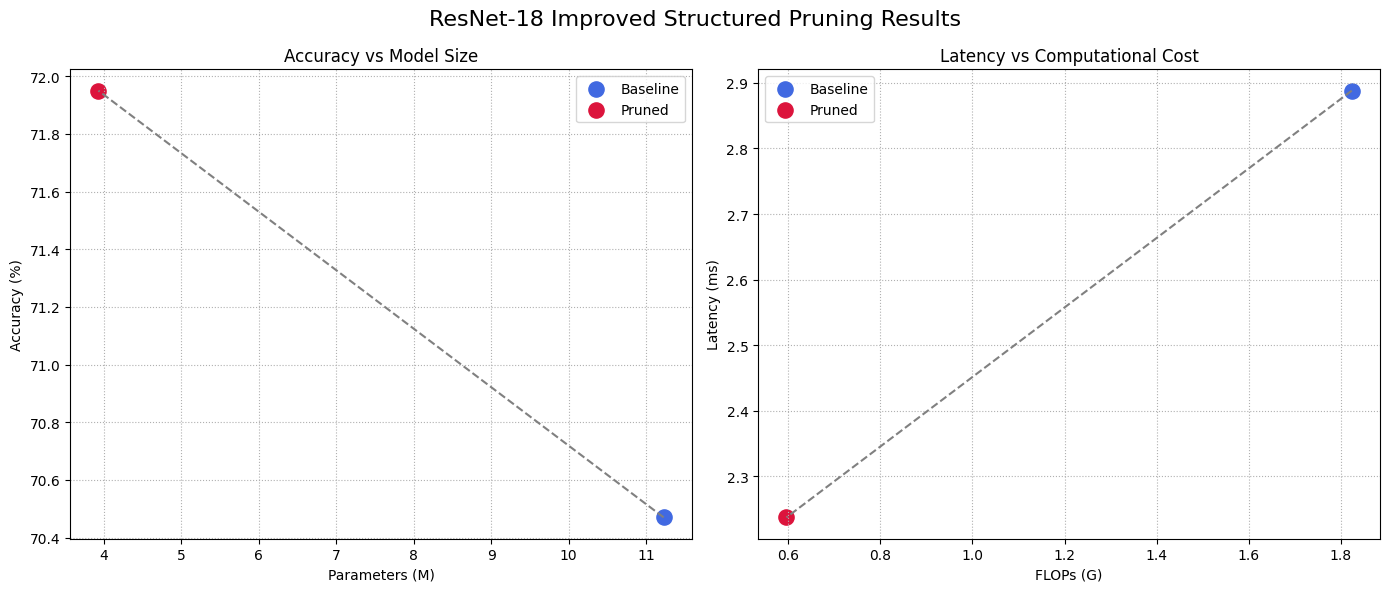

Figure saved to outputs/pruning_results.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(
    baseline_params_val, baseline_acc_val, color="royalblue", s=120, label="Baseline"
)
ax1.scatter(pruned_params_val, pruned_acc_val, color="crimson", s=120, label="Pruned")
ax1.plot(
    [baseline_params_val, pruned_params_val],
    [baseline_acc_val, pruned_acc_val],
    "--",
    color="gray",
)
ax1.set_xlabel("Parameters (M)")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy vs Model Size")
ax1.grid(True, linestyle=":")
ax1.legend()

ax2 = axes[1]
ax2.scatter(
    baseline_flops_val, baseline_lat_val, color="royalblue", s=120, label="Baseline"
)
ax2.scatter(pruned_flops_val, pruned_lat_val, color="crimson", s=120, label="Pruned")
ax2.plot(
    [baseline_flops_val, pruned_flops_val],
    [baseline_lat_val, pruned_lat_val],
    "--",
    color="gray",
)
ax2.set_xlabel("FLOPs (G)")
ax2.set_ylabel("Latency (ms)")
ax2.set_title("Latency vs Computational Cost")
ax2.grid(True, linestyle=":")
ax2.legend()

fig.suptitle("ResNet-18 Improved Structured Pruning Results", fontsize=16)
plt.tight_layout()
plt.show()

os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/pruning_results.png", dpi=300, bbox_inches="tight")
print("Figure saved to outputs/pruning_results.png")

### Cell 15: Export

In [39]:
print("=== EXPORTING ===")
os.makedirs("outputs", exist_ok=True)

# Save full pruned FP32 model
torch.save(model, "outputs/improved_pruned_resnet18.pth")

# ── TorchScript export ──
model_cpu = copy.deepcopy(model).cpu()
model_cpu.eval()
try:
    scripted = torch.jit.script(model_cpu)
    scripted.save("outputs/scripted_improved_pruned_resnet18.pt")
    print("TorchScript export: SUCCESS")
except Exception as e:
    print(f"Script failed ({e}), falling back to torch.jit.trace")
    traced = torch.jit.trace(model_cpu, torch.randn(1, 3, 224, 224))
    traced.save("outputs/traced_improved_pruned_resnet18.pt")
    print("TorchScript trace export: SUCCESS")

# ── Save final checkpoint to Drive ──
save_checkpoint(
    "exported",
    model,
    {
        "pruned_acc": pruned_acc,
        "pruned_params": pruned_params,
        "pruned_latency": pruned_latency,
    },
)

model = model.to(device)  # restore to GPU
print("All outputs saved to outputs/ directory.")

=== EXPORTING ===
TorchScript export: SUCCESS
  ✓ Checkpoint saved → /content/drive/MyDrive/pruning_research/cifar100_resnet18/exported.pth
All outputs saved to outputs/ directory.


### Final Evaluation Summary

In [40]:
model = model.to(device)
final_test_acc = evaluate(model, testloader)

print("\n--- Final Evaluation ---")
print(f"Pruned Model Test Accuracy : {final_test_acc:.2f}%")
print(f"Baseline Model Test Accuracy: {baseline_acc:.2f}%")
print(f"Net Change                 : {final_test_acc - baseline_acc:+.2f}%")
print(
    f"Parameter Reduction        : {(1 - pruned_params / baseline_params) * 100:.1f}%"
)
print(f"FLOPs Reduction            : {(1 - pruned_flops / baseline_flops) * 100:.1f}%")
print(
    f"Latency Reduction          : {(1 - pruned_latency / baseline_latency) * 100:.1f}%"
)


--- Final Evaluation ---
Pruned Model Test Accuracy : 71.95%
Baseline Model Test Accuracy: 70.47%
Net Change                 : +1.48%
Parameter Reduction        : 65.0%
FLOPs Reduction            : 67.3%
Latency Reduction          : 22.6%
